In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycountry

In [171]:
# LOADING THE DATASET
df = pd.read_csv("data/CFU.csv" )

In [172]:
# Preview first rows
df.head()

,Country,Contributor,Fund,Fund focus,Measure Names,Measure Values
0,Australia,Australia,Clean Technology Fund (CTF),Mitigation - General,Deposited (USD million current),86.33
1,Australia,Australia,Clean Technology Fund (CTF),Mitigation - General,Pledged (USD million current),86.33
2,Australia,Australia,Forest Carbon Partnership Facility - Carbon Fu...,Mitigation - REDD,Deposited (USD million current),18.39
3,Australia,Australia,Forest Carbon Partnership Facility - Carbon Fu...,Mitigation - REDD,Pledged (USD million current),18.39
4,Australia,Australia,Forest Carbon Partnership Facility - Readiness...,Mitigation - REDD,Deposited (USD million current),23.89


In [173]:
# CHECK FOR MISSING VALUES 
missing_values = df.isnull().sum()
missing_values

Country            0
Contributor        0
Fund               0
Fund focus         0
Measure Names      0
Measure Values    32
dtype: int64

In [174]:
# Select rows with missing values in any column
rows_with_missing = df[df.isnull().any(axis=1)]
rows_with_missing

,Country,Contributor,Fund,Fund focus,Measure Names,Measure Values
18,Australia,Australia,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
48,Austria,Austria,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
74,Belgium,Belgium,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
136,Canada,Canada,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
180,Czech republic,Czech republic,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
208,Denmark,Denmark,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
226,Estonia,Estonia,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
280,Finland,Finland,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
314,France,France,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN
352,Germany,Germany,Green Climate Fund (GCF-2),Multiple Foci,Deposited (USD million current),NaN


In [175]:
#  Basic dataset overview
df.info()  # info about columns and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         1000 non-null   object 
 1   Contributor     1000 non-null   object 
 2   Fund            1000 non-null   object 
 3   Fund focus      1000 non-null   object 
 4   Measure Names   1000 non-null   object 
 5   Measure Values  968 non-null    float64
dtypes: float64(1), object(5)
memory usage: 47.0+ KB


In [176]:
df.describe() # statistics for numeric columns

,Measure Values
count,968.000000
mean,107.662629
std,317.615072
min,0.000000
25%,2.620000
50%,14.145000
75%,71.682500
max,3000.000000


In [177]:
df.nunique() # number of unique values per column

Country            68
Contributor        87
Fund               28
Fund focus          4
Measure Names       2
Measure Values    524
dtype: int64

In [178]:
print(df["Fund focus"].unique())

['Mitigation - General' 'Mitigation - REDD' 'Multiple Foci' 'Adaptation']


In [179]:
# Exclude all Adaptation and Multiple Foci rows because they do not directly contribute to climate change mitigation
df_filtered = df[~df["Fund focus"].isin(["Adaptation", "Multiple Foci"])]
original_rows = df.shape[0]
filtered_rows = df_filtered.shape[0]
rows_removed = original_rows - filtered_rows

print(f"Original rows: {original_rows}")
print(f"Rows after filtering: {filtered_rows}")
print(f"Number of rows removed: {rows_removed}")

Original rows: 1000
Rows after filtering: 202
Number of rows removed: 798


In [180]:
# Pledged vs Deposited per donor country
df_filtered = df_filtered[df_filtered["Measure Names"].isin(["Pledged (USD million current)", "Deposited (USD million current)"])]
pledge_vs_deposit = df_filtered.groupby(["Contributor", "Measure Names"])["Measure Values"].sum().unstack(fill_value=0)
pledge_vs_deposit = pledge_vs_deposit.sort_values("Deposited (USD million current)", ascending=False)
pledge_vs_deposit.head(10)  # top 10 donors

Measure Names,Deposited (USD million current),Pledged (USD million current)
Contributor,,
United Kingdom,3016.4125,3175.040
United States,2739.1800,3239.180
Norway,2442.3700,2600.408
Germany,1860.8500,1888.720
Japan,1168.0100,1168.010
Canada,1042.0400,1042.041
France,250.4500,250.450
Australia,188.0400,188.040
Sweden,152.1100,152.110


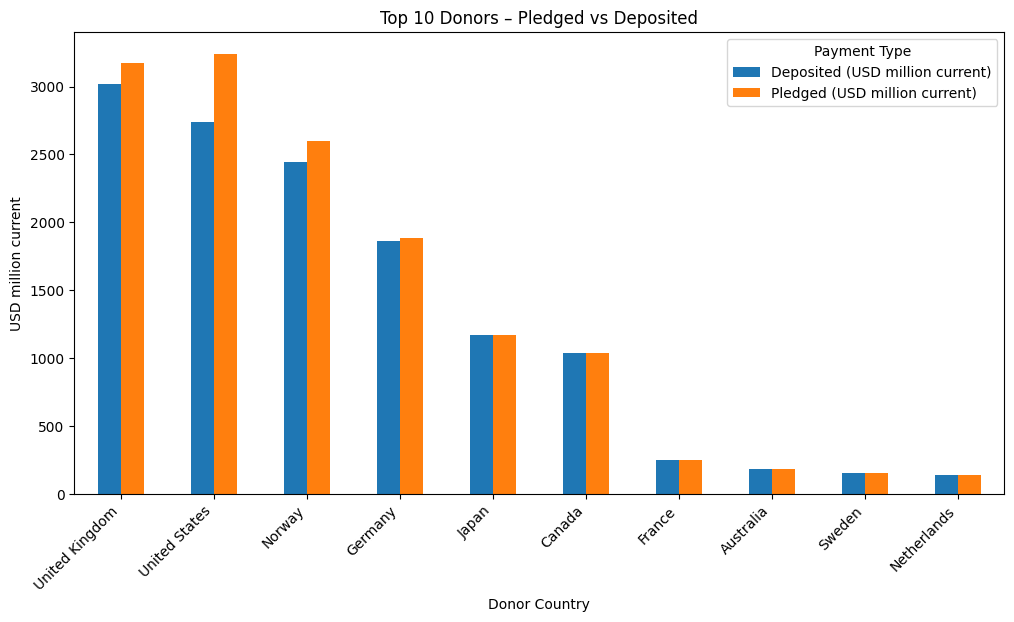

In [182]:
 # Visualization: Top 15 donors (Pledged vs Deposited)
top10 = pledge_vs_deposit.head(10)

ax = top10.plot(kind="bar", figsize=(12,6))
plt.title("Top 10 Donors – Pledged vs Deposited")
plt.ylabel("USD million current")
plt.xlabel("Donor Country")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Payment Type")
plt.show()

In [154]:
# Top recipient countries
receivers = (
    df_filtered
    .groupby(["Country", "Measure Names"])["Measure Values"]
    .sum()
    .unstack(fill_value=0)
)

# Sort by actual deposited amount
receivers = receivers.sort_values("Deposited (USD million current)", ascending=False)

receivers.head(10)

Measure Names,Deposited (USD million current),Pledged (USD million current)
Country,,
United Kingdom,3021.4125,3180.040
United States,2739.1800,3239.180
Norway,2442.3700,2600.408
Germany,1860.8500,1888.720
Japan,1168.0100,1168.010
Canada,1042.0400,1042.041
France,250.4500,250.450
Australia,188.0400,188.040
Europe,157.9800,187.560


In [155]:
df_vulnerability = pd.read_csv("data/vulnerability.csv" )

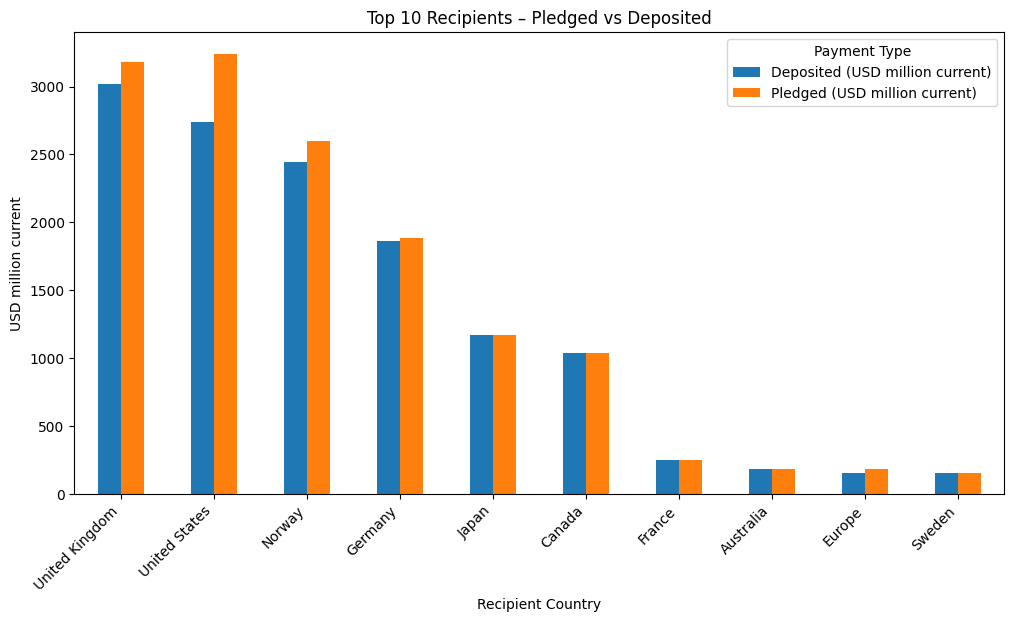

In [183]:
# Visualization: Top 10 recipients
top10_receivers = receivers.head(10)

ax = top10_receivers.plot(kind="bar", figsize=(12,6))
plt.title("Top 10 Recipients – Pledged vs Deposited")
plt.ylabel("USD million current")
plt.xlabel("Recipient Country")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Payment Type")
plt.show()

In [184]:
existing_goliati = [ "United States", "Japan", "Germany", "United Kingdom", "France"]
top_goliati = pledge_vs_deposit.loc[existing_goliati].copy()
top_goliati

Measure Names,Deposited (USD million current),Pledged (USD million current)
Contributor,,
United States,2739.1800,3239.18
Japan,1168.0100,1168.01
Germany,1860.8500,1888.72
United Kingdom,3016.4125,3175.04
France,250.4500,250.45


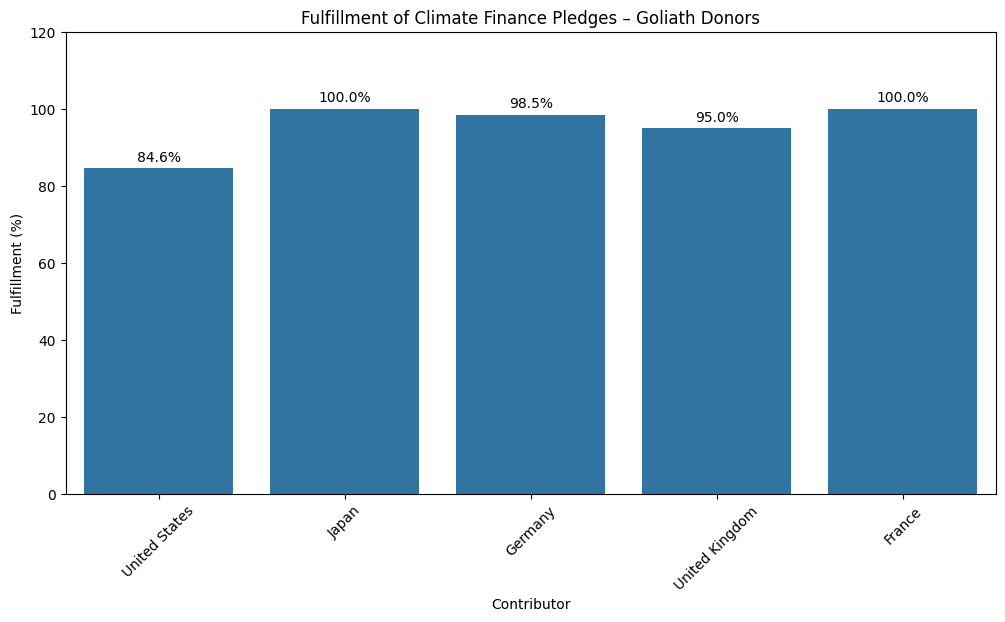

In [185]:
top_goliati['Fulfillment (%)'] = (
    top_goliati['Deposited (USD million current)'] / top_goliati['Pledged (USD million current)']
) * 100

plt.figure(figsize=(12,6))
barplot = sns.barplot(
    x=top_goliati.index, 
    y='Fulfillment (%)', 
    data=top_goliati, 
)

for i, value in enumerate(top_goliati['Fulfillment (%)']):
    barplot.text(i, value + 1, f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title("Fulfillment of Climate Finance Pledges – Goliath Donors")
plt.ylabel("Fulfillment (%)")
plt.xlabel("Contributor")
plt.ylim(0, 120)  # slightly above 100% for clarity
plt.xticks(rotation=45)
plt.show()

In [186]:
df_vulnerability.head()

,ISO3,Name,1995,1996,1997,1998,1999,2000,2001,2002,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,AFG,Afghanistan,0.612511,0.612679,0.612837,0.611179,0.609828,0.608398,0.606533,0.604601,...,0.587004,0.583233,0.588403,0.593829,0.591231,0.587843,0.582315,0.586000,0.587796,0.587516
1,ALB,Albania,0.451827,0.452691,0.450500,0.451614,0.458679,0.456919,0.458307,0.456054,...,0.415760,0.411555,0.412315,0.414393,0.407147,0.401351,0.395254,0.383450,0.380609,0.380184
2,DZA,Algeria,0.398323,0.397332,0.396046,0.392967,0.390274,0.388763,0.390600,0.393111,...,0.375612,0.376015,0.376073,0.377987,0.379167,0.381465,0.358463,0.369852,0.367361,0.367352
3,AND,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGO,Angola,0.493885,0.494235,0.494136,0.494037,0.494149,0.494392,0.496737,0.494951,...,0.504594,0.506422,0.507860,0.509298,0.512001,0.511537,0.513685,0.510007,0.508757,0.506373


In [187]:
# CHECK FOR MISSING VALUES 
missing_values = df_vulnerability.isnull().sum()
missing_values

ISO3    0
Name    0
1995    5
1996    5
1997    5
1998    5
1999    5
2000    5
2001    5
2002    5
2003    5
2004    5
2005    5
2006    5
2007    5
2008    5
2009    5
2010    5
2011    5
2012    5
2013    5
2014    5
2015    5
2016    5
2017    5
2018    5
2019    5
2020    5
2021    5
2022    5
2023    5
dtype: int64

In [188]:
# Select rows with missing values in any column
rows_with_missing = df_vulnerability[df_vulnerability.isnull().any(axis=1)]
rows_with_missing


,ISO3,Name,1995,1996,1997,1998,1999,2000,2001,2002,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
3,AND,Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,LIE,Liechtenstein,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,MCO,Monaco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143,KNA,Saint Kitts and Nevis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,SMR,San Marino,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [189]:
df_vulnerability = df_vulnerability.dropna()

In [191]:
# Select only the year columns (1995-2023)
year_columns = [col for col in df_vulnerability.columns if col.isdigit()]

# Calculate row-wise average across all year columns
df_vulnerability["Vulnerability_Avg"] = df_vulnerability[year_columns].mean(axis=1)

# Keep only country info and the new average column
df_vulnerability_avg = df_vulnerability[["ISO3", "Name", "Vulnerability_Avg"]]